In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import csv
import pandas as pd
import matplotlib.pyplot as plt
import math

alfredo =pd.read_csv("/content/drive/My Drive/Colab Notebooks/Compostec/ALFREDO_TESTE_CAMPO_NH3.csv")
zugam = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Compostec/ZUGAM_TESTE_CAMPO_NH3_AVG.csv")

# Remove linhas completamente vazias
alfredo = alfredo.dropna(how='all')
zugam = zugam.dropna(how='all')

# Substitui vírgula por ponto na coluna (assume que é string)
alfredo['NH3-ppb'] = alfredo['NH3-ppb'].astype(str).str.replace(',', '.', regex=False)
zugam['NH3-ppb'] = zugam['NH3-ppb'].astype(str).str.replace(',', '.', regex=False)
zugam['speed-avg'] = zugam['speed-avg'].astype(str).str.replace(',', '.', regex=False)
zugam['speed-max'] = zugam['speed-max'].astype(str).str.replace(',', '.', regex=False)
zugam['vane-avg'] = zugam['vane-avg'].astype(str).str.replace(',', '.', regex=False)

# Converte a coluna para tipo numérico
alfredo['NH3-ppb'] = pd.to_numeric(alfredo['NH3-ppb'], errors='coerce')  # converte e trata erros
zugam['NH3-ppb'] = pd.to_numeric(zugam['NH3-ppb'], errors='coerce')  # converte e trata erros
zugam['speed-avg'] = pd.to_numeric(zugam['speed-avg'], errors='coerce')  # converte e trata erros
zugam['speed-max'] = pd.to_numeric(zugam['speed-max'], errors='coerce')  # converte e trata erros
zugam['vane-avg'] = pd.to_numeric(zugam['vane-avg'], errors='coerce')  # converte e trata erros

# Substitui NaN por zero
alfredo['NH3-ppb'] = alfredo['NH3-ppb'].fillna(0)
zugam['NH3-ppb'] = zugam['NH3-ppb'].fillna(0)
zugam['speed-avg'] = zugam['speed-avg'].fillna(0)
zugam['speed-max'] = zugam['speed-max'].fillna(0)
zugam['vane-avg'] = zugam['vane-avg'].fillna(0)

# Adiciona a nova coluna com valor padrão (pode ser vazio ou outro valor)
alfredo['NH3-ppb-zugam'] = alfredo.get('NH3-ppb-zugam', 0)
alfredo['speed-avg'] = alfredo.get('speed-avg', 0)
alfredo['speed-max'] = alfredo.get('speed-max', 0)
alfredo['vane-avg'] = alfredo.get('vane-avg', 0)

# Mantém apenas as 47.000 primeiras linhas
alfredo = alfredo.head(46900)

# Converte a coluna para datetime corretamente — formato original "%d/%m/%Y %H:%M:%S"
#zugam['TIME'] = zugam['TIME'].astype(str).str.strip()
#zugam['TIME'] = pd.to_datetime(zugam['TIME'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

#zugam.head(5)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-9-237209319.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nova_tabela = pd.concat([nova_tabela, pd.DataFrame([nova_linha])], ignore_index=True)


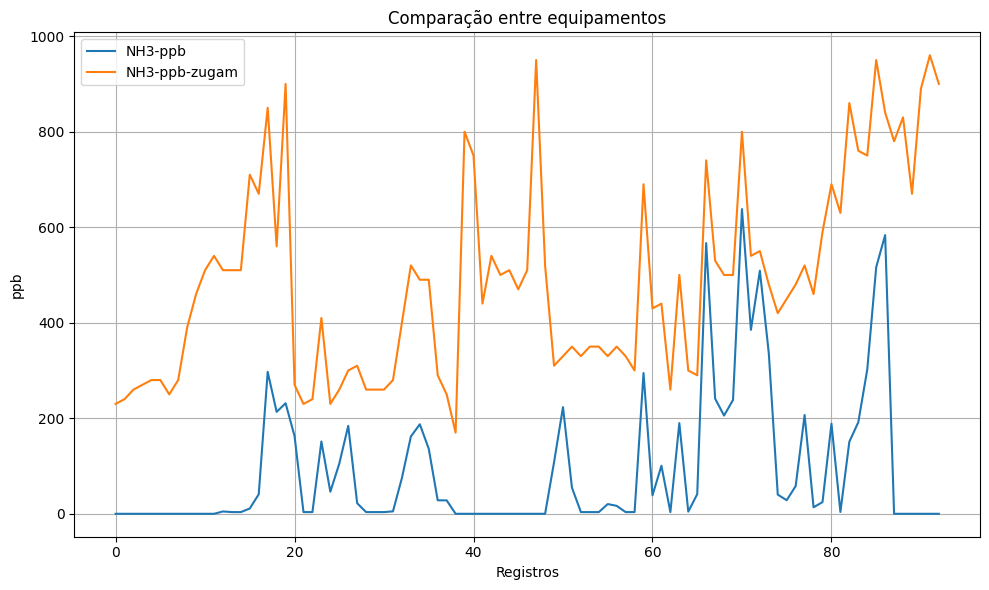

In [ ]:
# Percorre cada linha
for index, row in zugam.iterrows():

    # Cria a nova linha como dicionário
    if index > 0:
      nova_linha = {'TIME': row['TIME'], 'NH3-ppb': 0, 'NH3-ppb-zugam': row['NH3-ppb'],
                  'speed-avg': zugam.loc[index - 1, 'speed-avg'],
                  'speed-max': zugam.loc[index - 1, 'speed-max'],
                  'vane-avg': zugam.loc[index - 1, 'vane-avg']
                  }
    else:
      nova_linha = {'TIME': row['TIME'], 'NH3-ppb': 0, 'NH3-ppb-zugam': row['NH3-ppb'],
                  'speed-avg': row['speed-avg'],
                  'speed-max': row['speed-max'],
                  'vane-avg': row['vane-avg']
                  }

    # Adiciona a nova linha ao DataFrame
    alfredo = pd.concat([alfredo, pd.DataFrame([nova_linha])], ignore_index=True)

# Ordenar pela coluna de data e hora
alfredo_ordenado = alfredo.sort_values(by='TIME')

# Substitui NaN por zero
alfredo_ordenado['NH3-ppb'] = alfredo_ordenado['NH3-ppb'].fillna(0)
alfredo_ordenado['NH3-ppb-zugam'] = alfredo_ordenado['NH3-ppb-zugam'].fillna(0)

# Substitui espaços em branco por 0 na coluna
alfredo_ordenado['NH3-ppb'] = alfredo_ordenado['NH3-ppb'].replace(' ', '0', regex=False)
alfredo_ordenado['NH3-ppb-zugam'] = alfredo_ordenado['NH3-ppb-zugam'].replace(' ', '0', regex=False)

# Removendo as primeiras 221 linhas
#alfredo_ordenado = alfredo_ordenado.iloc[222:]

# Salva de volta
#alfredo_ordenado.to_csv('/content/drive/My Drive/Colab Notebooks/Compostec/MOD_MEDIA/ZUGAM_ALFREDO_TESTE_CAMPO_NH3.csv', index=False)

#---------------------------------------------------------------------------
#CRIAR NOVA TABELA COM MÉDIA DO ALFREDO PAREADO COM OS DADOS DA ZUGAM
#---------------------------------------------------------------------------
nova_tabela = pd.DataFrame(columns=['TIME', 'NH3-ppb', 'NH3-ppb-zugam', 'speed-avg', 'speed-max', 'vane-avg'])

# Converter a coluna para número inteiro
nova_tabela['NH3-ppb'] = pd.to_numeric(nova_tabela['NH3-ppb'],errors='coerce')
nova_tabela['NH3-ppb-zugam'] = pd.to_numeric(nova_tabela['NH3-ppb-zugam'],errors='coerce')

tot_media_nh3_ppb = 0
count_nh3_ppb = 0

# Percorre cada linha
for index, row in alfredo_ordenado.iterrows():

    tot_media_nh3_ppb = tot_media_nh3_ppb + float(row['NH3-ppb'])
    count_nh3_ppb = count_nh3_ppb + 1

    if row['NH3-ppb-zugam'] > 0 and count_nh3_ppb != 0:

      tot_media_nh3_ppb = tot_media_nh3_ppb/count_nh3_ppb
      tot_media_nh3_ppb = math.trunc(tot_media_nh3_ppb * 100) / 100

      nova_linha = {'TIME': row['TIME'], 'NH3-ppb': tot_media_nh3_ppb, 'NH3-ppb-zugam': row['NH3-ppb-zugam'],
                    'speed-avg': row['speed-avg'], 'speed-max': row['speed-max'], 'vane-avg': row['vane-avg']}

      nova_tabela = pd.concat([nova_tabela, pd.DataFrame([nova_linha])], ignore_index=True)

      tot_media_nh3_ppb = 0
      count_nh3_ppb = 0



# Salva de volta
nova_tabela.to_csv('/content/drive/My Drive/Colab Notebooks/Compostec/MOD_MEDIA/MEDIA_ALFREDO_TESTE_CAMPO_NH3.csv', index=False)

# Plotar grafico
# Seleciona as colunas a serem plotadas
coluna1 = 'NH3-ppb'
coluna2 = 'NH3-ppb-zugam'

# Cria o gráfico com índice como eixo X
plt.figure(figsize=(10, 6))
plt.plot(nova_tabela[coluna1], label=coluna1)
plt.plot(nova_tabela[coluna2], label=coluna2)

# Formatação
plt.xlabel('Registros')
plt.ylabel('ppb')
plt.title('Comparação entre equipamentos')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Exibe o gráfico
plt.show()

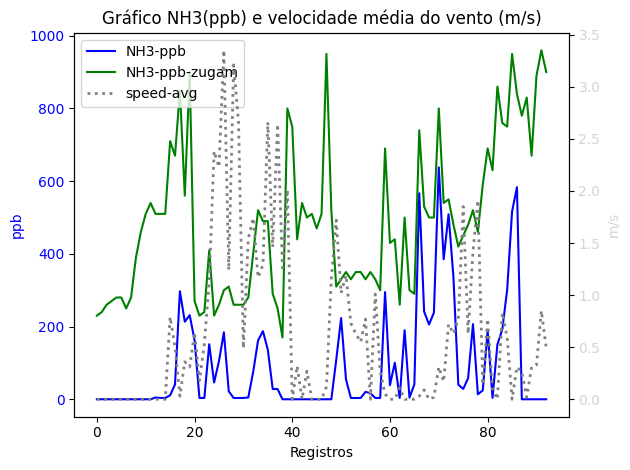

In [ ]:
# Cria a figura e o primeiro eixo Y
fig, ax1 = plt.subplots()

# Plota o primeiro eixo Y (ex: y1)
line1, = ax1.plot(nova_tabela['NH3-ppb'], 'b-', label='NH3-ppb')
line2, = ax1.plot(nova_tabela['NH3-ppb-zugam'], 'g-', label='NH3-ppb-zugam')
ax1.set_xlabel('Registros')
ax1.set_ylabel('ppb', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Cria o segundo eixo Y (compartilha o eixo X)
ax2 = ax1.twinx()
line3, = ax2.plot(
    nova_tabela['speed-avg'],              # Eixo Y (índice será eixo X)
    color='gray',                     # Cor cinza claro
    linestyle=':',                         # Linha pontilhada
    linewidth=2,                           # Espessura da linha (opcional)
    label='speed-avg'                      # Nome na legenda
)
ax2.set_ylabel('m/s', color='lightgray')
ax2.tick_params(axis='y', labelcolor='lightgray')

# Junta as legendas dos dois eixos
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

# Título e layout
plt.title('Gráfico NH3(ppb) e velocidade média do vento (m/s)')
plt.tight_layout()
plt.show()